# 8. Como usar o QMI

**Objetivos:** construir uma amplitude QMI, entender a interpolação em \$s=m^2\$, usar nós polares e cartesianos e inserir o QMI em um modelo de Dalitz.

O QMI (*quasi-model-independent*) descreve um S-wave por valores fornecidos em nós de massa. Ele não escolhe uma fórmula de ressonância: a amplitude entre os nós é interpolada. Este notebook usa apenas dados simulados e não representa uma medida publicada.

Execute as células em ordem em um kernel novo. Massas estão em GeV, invariantes em GeV² e os índices das filhas começam em zero.

In [8]:
from dalitzplotfitter import enable_x64
enable_x64()

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from dalitzplotfitter import (
    DecayChannel, DecayModel, NonResonant, QMI, RealImag, Resonance,
    generate_toy,
)

## 1. QMI polar: magnitude e fase nos nós

Na parametrização polar, cada nó representa
\[A_S(s_k)=a_k e^{i\delta_k}.\]

Os `knots` são massas, mas a interpolação acontece em \$s=m^2\$. Use fases contínuas, sem reiniciar a fase em \$-\pi\$ ou \$\pi\$ entre nós.

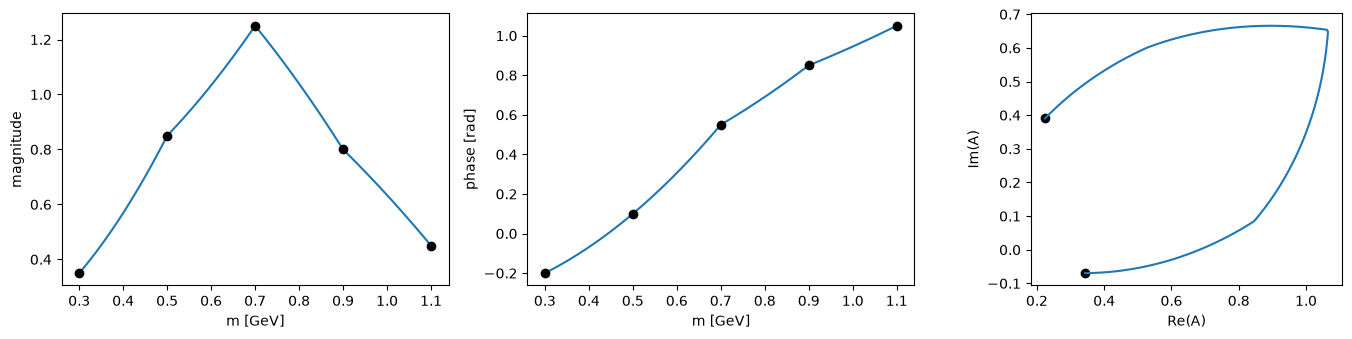

In [9]:
knots = (0.30, 0.50, 0.70, 0.90, 1.10)
magnitudes = (0.35, 0.85, 1.25, 0.80, 0.45)
phases = (-0.20, 0.10, 0.55, 0.85, 1.05)

qmi_linear = QMI(
    knots=knots, magnitudes=magnitudes, phases=phases,
    interpolation="linear",
)

mass_scan = jnp.linspace(knots[0], knots[-1], 300)
magnitude_scan, phase_scan = qmi_linear.interpolated_magnitude_phase(mass_scan)
amplitude_scan = magnitude_scan * jnp.exp(1j * phase_scan)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].plot(mass_scan, magnitude_scan)
axes[0].scatter(knots, magnitudes, color="black", zorder=3)
axes[0].set(xlabel="m [GeV]", ylabel="magnitude")
axes[1].plot(mass_scan, phase_scan)
axes[1].scatter(knots, phases, color="black", zorder=3)
axes[1].set(xlabel="m [GeV]", ylabel="phase [rad]")
axes[2].plot(np.asarray(amplitude_scan).real, np.asarray(amplitude_scan).imag)
axes[2].scatter(np.asarray(amplitude_scan).real[[0, -1]], np.asarray(amplitude_scan).imag[[0, -1]], color="black")
axes[2].set(xlabel="Re(A)", ylabel="Im(A)", aspect="equal")
fig.tight_layout()
plt.show()

O valor nos nós deve ser reproduzido exatamente. Fora do intervalo, o QMI mantém o valor do nó mais próximo (*clamping*).

In [10]:
knot_magnitudes, knot_phases = qmi_linear.interpolated_magnitude_phase(jnp.asarray(knots))
np.testing.assert_allclose(knot_magnitudes, magnitudes, atol=1e-11)
np.testing.assert_allclose(knot_phases, phases, atol=1e-11)
print("Todos os nós foram reproduzidos.")
print("Massa abaixo do primeiro nó:", qmi_linear.interpolated_magnitude_phase(jnp.asarray(0.20)))
print("Massa acima do último nó:", qmi_linear.interpolated_magnitude_phase(jnp.asarray(1.20)))

Todos os nós foram reproduzidos.
Massa abaixo do primeiro nó: (Array(0.35, dtype=float64), Array(-0.2, dtype=float64))
Massa acima do último nó: (Array(0.45, dtype=float64), Array(1.05, dtype=float64))


## 2. Comparar modos de interpolação

Além de `linear`, a classe oferece `cubic`, `hermite` e `natural`. Todos passam pelos nós; os modos suaves podem produzir valores intermediários diferentes e, em modelos polares, até *overshoot* na magnitude. `linear` é a escolha mais direta para reproduzir a convenção publicada usada como referência pelo projeto.

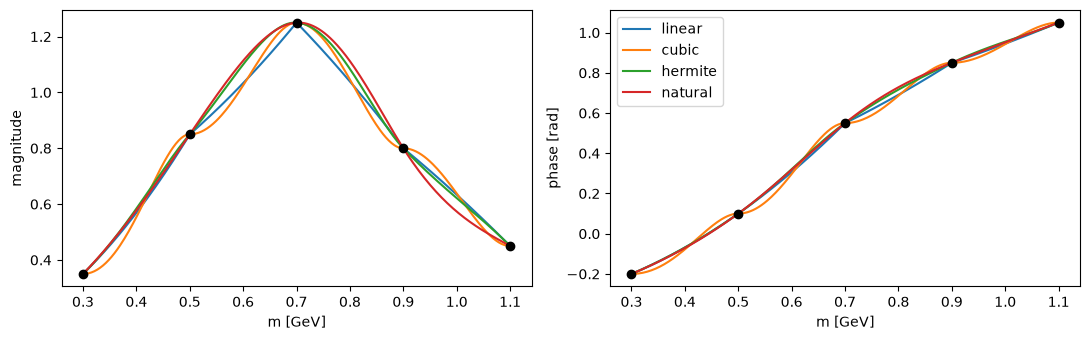

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for interpolation in ("linear", "cubic", "hermite", "natural"):
    qmi = QMI(knots, magnitudes, phases, interpolation=interpolation)
    magnitude, phase = qmi.interpolated_magnitude_phase(mass_scan)
    axes[0].plot(mass_scan, magnitude, label=interpolation)
    axes[1].plot(mass_scan, phase, label=interpolation)
axes[0].scatter(knots, magnitudes, color="black", zorder=3)
axes[0].set(xlabel="m [GeV]", ylabel="magnitude")
axes[1].scatter(knots, phases, color="black", zorder=3)
axes[1].set(xlabel="m [GeV]", ylabel="phase [rad]")
axes[1].legend()
fig.tight_layout()
plt.show()

## 3. Parametrização cartesiana

Quando magnitude e fase ficam mal condicionadas, especialmente perto de magnitude zero, é possível interpolar diretamente `real_parts` e `imaginary_parts`. A amplitude é
\[A_S(s)=x(s)+iy(s).\]

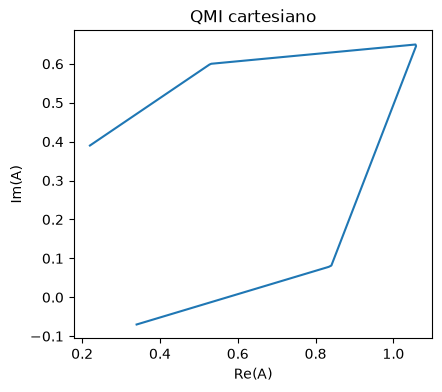

In [23]:
cartesian = QMI(
    knots=knots,
    real_parts=(0.34, 0.84, 1.06, 0.53, 0.22),
    imaginary_parts=(-0.07, 0.08, 0.65, 0.60, 0.39),
    interpolation="linear",
)
real_scan, imaginary_scan = cartesian.interpolated_cartesian(mass_scan)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(real_scan, imaginary_scan)
ax.set(xlabel="Re(A)", ylabel="Im(A)", title="QMI cartesiano", aspect="equal")
plt.show()

## 4. Colocar o QMI em um modelo de Dalitz

O QMI de uma dimensão é usado como qualquer outra `lineshape` de uma `Resonance`. Aqui ele descreve o par `(0, 1)` e recebe um coeficiente complexo. A normalização determinística e a interferência com os demais componentes continuam sob responsabilidade do `DecayModel`.

In [15]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))
model = DecayModel(
    channel,
    components=[
        Resonance(
            name="S_QMI", pair=(0, 1), coefficient=RealImag(1.0, 0.0),
            lineshape=qmi_linear, mass=0.90, width=0.10, spin=0,
            normalize_component=False,
        ),
        NonResonant(RealImag(0.25, -0.10), name="NR"),
    ],
    normalization_method="square-dalitz",
    normalization_pair=(0, 1),
    normalization_resolution=60,
)
proposal = model.generate_phase_space(4000, seed=8, include_momenta=False)
print("Componentes:", [component.name for component in model.components])
print("Eventos de fase espacial:", proposal.size)

Componentes: ['S_QMI', 'NR']
Eventos de fase espacial: 4000


Toy QMI gerado com 1200 eventos.


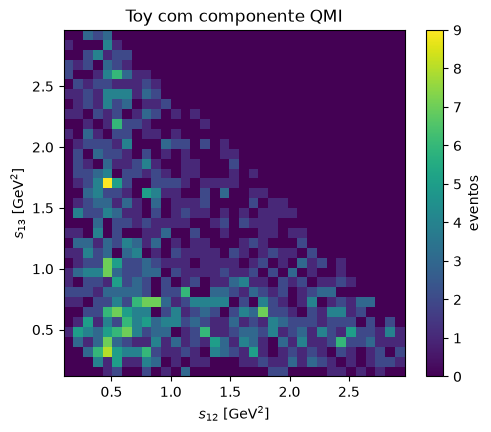

In [16]:
truth = {parameter.name: parameter.value for parameter in model.parameters}
toy = generate_toy(
    model, 1200, parameters=truth, seed=8,
    method="inverse-transform", inverse_resolution=256,
    include_momenta=False,
)
print(f"Toy QMI gerado com {toy.size} eventos.")
plt.figure(figsize=(5.5, 4.5))
plt.hist2d(np.asarray(toy.s12), np.asarray(toy.s13), bins=35)
plt.xlabel(r"$s_{12}$ [GeV$^2$]")
plt.ylabel(r"$s_{13}$ [GeV$^2$]")
plt.title("Toy com componente QMI")
plt.colorbar(label="eventos")
plt.show()

## Resumo e exercícios

1. Escolha os nós com cobertura suficiente da região física do par de partículas.
2. Compare `normalize_component=True` e `False`: a segunda opção deixa o componente bruto, mas ele ainda participa da matriz completa de normalização e da interferência.
3. Troque o QMI polar por `cartesian` no `Resonance` e compare os toys.
4. Para um ajuste real, transforme os valores dos nós em `Parameter.dynamics(..., owner="S_QMI")` e valide a estabilidade com diferentes inicializações.

Continue em [QMI S-wave isobar closure](../data_analyses/23_b2pipipi_qmi_isobar_closure_no_cp.ipynb). Consulte também [lineshapes](../../docs/lineshapes.md) e [fitting](../../docs/fitting.md).